<a href="https://colab.research.google.com/github/JennaSanks/Exploratory-Data-Analysis-EDA-using-Python/blob/main/ML_Exp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis (EDA) using Python

**Datasets used in this notebook**

| Dataset | Why we use it |
|---|---|
|  Titanic | Missing values, categorical data, cleaning, encoding |
|  Iris | Pure numerical analysis, pair plots, classification |
|  Tips | GroupBy, statistics, visualization |
|  Penguins | Missing values + mixed data types |
|  California Housing | Scaling & correlation on larger numerical data |

>

##  Table of Contents

0. Introduction to Data & Datasets
1. The Data Science Workflow
2. Import Libraries
3. Loading Datasets
4. First Look at a Dataset
5. Understanding Variable Types
6. Dataset Summary
7. Statistical Concepts
8. Missing Values
9. Duplicate Values
10. Unique Values
11. Correlation
12. Outliers
13. Feature Scaling
14. Encoding Categorical Data
15. Data Visualization (the big one!)
16. GroupBy & Aggregation
17. Full Data Cleaning Project (Titanic)
18. Mini Guided EDA Project (Tips)
19. Professional EDA Checklist
20. Practice Questions (MCQ)
21. Programming Exercises
22. Mini Assignment (Penguins)
23. Interview Questions
24. Final Summary / Cheat Sheet

---
#  Introduction: What is Data & What is a Dataset?

**Data** is any raw fact or observation — a number, a word, an image, a sound.
On its own, a single piece of data doesn't tell you much (e.g. `21`).

A **Dataset** is an organized collection of data, usually arranged as a **table** of
**rows** and **columns**, where the data becomes meaningful.

### Rows vs Columns
- **Row** → one single *observation / record / sample* (e.g. one student).
- **Column** → one *variable / feature* measured for every row (e.g. `Age`).

### Feature vs Target
- **Features (X)** → the input columns used to make a prediction.
- **Target (y)** → the output column we want to predict (only exists in supervised ML).

### Numerical vs Categorical
- **Numerical** → measurable quantities (`Age`, `CGPA`, `Salary`).
- **Categorical** → labels / groups (`Gender`, `Placed`, `City`).

### Structured vs Unstructured Data
- **Structured** → fits neatly into rows & columns (Excel sheet, SQL table, CSV).
- **Unstructured** → no fixed format (images, audio, free text, video).

### Example: A Simple Student Dataset

In [ ]:
import pandas as pd

# A tiny hand-made dataset to illustrate the concepts above
student_data = {
    "RollNo": [1, 2, 3, 4, 5],
    "Name":   ["Aarav", "Diya", "Kabir", "Meera", "Ishan"],
    "Age":    [19, 20, 19, 21, 20],
    "Gender": ["M", "F", "M", "F", "M"],
    "CGPA":   [8.4, 9.1, 7.8, 8.9, 7.2],
    "Placed": ["Yes", "Yes", "No", "Yes", "No"],
}

student_df = pd.DataFrame(student_data)
student_df   # displaying the DataFrame

,RollNo,Name,Age,Gender,CGPA,Placed
0,1,Aarav,19,M,8.4,Yes
1,2,Diya,20,F,9.1,Yes
2,3,Kabir,19,M,7.8,No
3,4,Meera,21,F,8.9,Yes
4,5,Ishan,20,M,7.2,No


---
#  The Data Science Workflow

Every real-world Data Science / ML project follows roughly the same pipeline.
EDA (this whole notebook!) covers the **middle three stages** — and they usually
take up **70–80% of a data scientist's total project time**.

```
┌───────────────┐
│ Collect Data  │
└───────┬───────┘
        ▼
┌───────────────┐
│ Understand    │
│ Data          │   <── EDA
└───────┬───────┘        starts
        ▼                 here
┌───────────────┐
│ Clean Data    │
└───────┬───────┘        EDA
        ▼                 ends
┌───────────────┐        here
│ Visualize     │
│ Data          │
└───────┬───────┘
        ▼
┌───────────────┐
│ Feature       │
│ Engineering   │
└───────┬───────┘
        ▼
┌───────────────┐
│ Machine       │
│ Learning      │
└───────┬───────┘
        ▼
┌───────────────┐
│ Evaluation    │
└───────┬───────┘
        ▼
┌───────────────┐
│ Deployment    │
└───────────────┘
```

> **Best practice:** Never jump straight into building a model. A model trained on
> dirty, misunderstood data will always give unreliable results — **"Garbage in, garbage out."**

---
# Import Libraries

| Library | Why we need it |
|---|---|
| **NumPy** | Fast numerical computing; the foundation every other library is built on |
| **Pandas** | Loading, cleaning, and manipulating tabular data (DataFrames) |
| **Matplotlib** | The base plotting library — full control over every visual element |
| **Seaborn** | Beautiful statistical plots built on top of Matplotlib, works great with Pandas |
| **Scikit-learn** | Preprocessing tools (scaling, encoding) and ML algorithms |

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing (used later for scaling & encoding)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, Normalizer,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)

# Display / plotting settings
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")

All libraries imported successfully!


---
#  Loading Datasets

We'll load **five** classic, beginner-friendly datasets. Each teaches a different EDA skill.

| Dataset | Load with | Best for |
|---|---|---|
| Titanic | `sns.load_dataset('titanic')` | Missing values, categorical data, full cleaning |
| Iris | `sns.load_dataset('iris')` | Pure numerical analysis, pairplots |
| Tips | `sns.load_dataset('tips')` | GroupBy, aggregation, visualization |
| Penguins | `sns.load_dataset('penguins')` | Missing values, mixed data types |
| California Housing | `sklearn.datasets.fetch_california_housing` | Scaling & correlation on larger numeric data |

**Titanic will be our main "storyline" dataset** — we'll keep coming back to it throughout
the notebook. The others appear where they best illustrate a concept.

In [ ]:
# Load all datasets we will use in this notebook
titanic  = sns.load_dataset("titanic")
iris     = sns.load_dataset("iris")
tips     = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")

print("Titanic :", titanic.shape)
print("Iris    :", iris.shape)
print("Tips    :", tips.shape)
print("Penguins:", penguins.shape)

Titanic : (891, 15)
Iris    : (150, 5)
Tips    : (244, 7)
Penguins: (344, 7)


In [ ]:
# California Housing — a larger, purely numerical dataset (fetched from scikit-learn)
from sklearn.datasets import fetch_california_housing

try:
    housing_bunch = fetch_california_housing(as_frame=True)
    housing = housing_bunch.frame
except Exception as e:
    # Fallback: if there is no internet access, build a similar synthetic dataset
    print("Could not download California Housing, generating a similar synthetic dataset instead.")
    from sklearn.datasets import make_regression
    X, y = make_regression(n_samples=2000, n_features=8, noise=15, random_state=42)
    cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
            "Population", "AveOccup", "Latitude", "Longitude"]
    housing = pd.DataFrame(X, columns=cols)
    housing["MedHouseVal"] = y

print("California Housing:", housing.shape)
housing.head()

California Housing: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Check Built-in Dataset from a library**

In [ ]:
import seaborn as sns
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

**The dir() function lists all attributes, functions, classes, and datasets available in a module.**

In [ ]:
import plotly.express as px
dir(px.data)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'carshare',
 'election',
 'election_geojson',
 'experiment',
 'gapminder',
 'iris',
 'medals_long',
 'medals_wide',
 'stocks',
 'tips',
 'wind']

In [ ]:
import seaborn as sns
dir(sns)

['FacetGrid',
 'JointGrid',
 'PairGrid',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_base',
 '_compat',
 '_core',
 '_docstrings',
 '_orig_rc_params',
 '_statistics',
 '_stats',
 'algorithms',
 'axes_style',
 'axisgrid',
 'barplot',
 'blend_palette',
 'boxenplot',
 'boxplot',
 'categorical',
 'catplot',
 'choose_colorbrewer_palette',
 'choose_cubehelix_palette',
 'choose_dark_palette',
 'choose_diverging_palette',
 'choose_light_palette',
 'clustermap',
 'cm',
 'color_palette',
 'colors',
 'countplot',
 'crayon_palette',
 'crayons',
 'cubehelix_palette',
 'dark_palette',
 'desaturate',
 'despine',
 'displot',
 'distplot',
 'distributions',
 'diverging_palette',
 'dogplot',
 'ecdfplot',
 'external',
 'get_data_home',
 'get_dataset_names',
 'heatmap',
 'histplot',
 'hls_palette',
 'husl_palette',
 'jointplot',
 'kdeplot',
 'light_palette',
 'lineplot',
 'lmplot',
 'load_dataset',
 'matrix

---
#  First Look at a Dataset

Before doing anything else, always run these commands on a new dataset (using **Titanic**).

In [ ]:
titanic.head()   # first 5 rows — a quick peek at the data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
titanic.tail()   # last 5 rows — useful to check if data ends correctly (no junk rows)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
titanic.sample(5)   # 5 random rows — helps you see rows head()/tail() might miss

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
391,1,3,male,21.0,0,0,7.7958,S,Third,man,True,NaN,Southampton,yes,True
612,1,3,female,NaN,1,0,15.5000,Q,Third,woman,False,NaN,Queenstown,yes,False
530,1,2,female,2.0,1,1,26.0000,S,Second,child,False,NaN,Southampton,yes,False
336,0,1,male,29.0,1,0,66.6000,S,First,man,True,C,Southampton,no,False
486,1,1,female,35.0,1,0,90.0000,S,First,woman,False,C,Southampton,yes,False


In [ ]:
print("Shape (rows, columns):", titanic.shape)
print("Size (total values)  :", titanic.size)
print("Dimensions (ndim)    :", titanic.ndim)

Shape (rows, columns): (891, 15)
Size (total values)  : 13365
Dimensions (ndim)    : 2


In [ ]:
print("Columns:\n", list(titanic.columns))
print("\nIndex:", titanic.index)

Columns:
 ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Index: RangeIndex(start=0, stop=891, step=1)


---
#  Understanding Variable Types

```
                       Variable Types
                             │
            ┌────────────────┴────────────────┐
            ▼                                  ▼
       Numerical                          Categorical
            │                                  │
   ┌────────┴────────┐             ┌───────────┼───────────┐
   ▼                  ▼             ▼           ▼           ▼
Continuous        Discrete       Nominal     Ordinal      Binary
(can take any    (countable,   (no order:   (has order:  (only 2
 value, e.g.      e.g. no. of   e.g. City,   e.g. Grade   categories,
 Height, Fare)    siblings)     Gender)      A>B>C)       e.g. Yes/No)
```

| Type | Definition | Titanic Example |
|---|---|---|
| Continuous | Can take any value in a range | `fare`, `age` |
| Discrete | Countable whole numbers | `sibsp` (siblings/spouses), `parch` |
| Nominal | Categories with **no** order | `sex`, `embarked` |
| Ordinal | Categories **with** order | `pclass` (1st > 2nd > 3rd class) |
| Binary | Exactly two categories | `survived` (0/1), `alone` (True/False) |

>  **Tip:** Correctly identifying variable type decides *which plot* and *which
> preprocessing method* (scaling vs encoding) you'll use later in this notebook.

In [ ]:
# Let's classify Titanic's columns ourselves
titanic.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


---
#  Dataset Summary

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
titanic.describe()   # summary statistics for NUMERICAL columns only

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic.describe(include="all")   # summary for ALL columns (numeric + categorical)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# Statistical Concepts

Let's understand the numbers behind `describe()` using the `age` column.

```
        Min        Q1(25%)      Median(Q2)     Q3(75%)        Max
         |            |               |             |           |
  ───────┼────────────┼───────────────┼─────────────┼───────────┼──────►
         └────── IQR = Q3 − Q1 ────────┘
                (middle 50% of the data)
```

| Concept | Meaning | Formula / Note |
|---|---|---|
| **Mean** | Average value | sum of values ÷ count |
| **Median** | Middle value when sorted | robust to outliers |
| **Mode** | Most frequently occurring value | works for numeric & categorical |
| **Variance** | Average squared distance from the mean | spread of data |
| **Std. Deviation** | Square root of variance | spread, in original units |
| **Quartiles** | Values that split sorted data into 4 equal parts | Q1, Q2 (median), Q3 |
| **Percentile** | Value below which a given % of data falls | e.g. 90th percentile |
| **Range** | Max − Min | total spread |
| **IQR** | Q3 − Q1 | spread of the middle 50%, used for outlier detection |

In [ ]:
age = titanic["age"].dropna()   # drop missing values just for this calculation

print("Mean               :", round(age.mean(), 2))
print("Median              :", round(age.median(), 2))
print("Mode                :", age.mode()[0])
print("Variance            :", round(age.var(), 2))
print("Standard Deviation  :", round(age.std(), 2))
print("Q1 (25th percentile):", age.quantile(0.25))
print("Q3 (75th percentile):", age.quantile(0.75))
print("90th Percentile     :", age.quantile(0.90))
print("Range               :", age.max() - age.min())
print("IQR (Q3 - Q1)       :", age.quantile(0.75) - age.quantile(0.25))

Mean               : 29.7
Median              : 28.0
Mode                : 24.0
Variance            : 211.02
Standard Deviation  : 14.53
Q1 (25th percentile): 20.125
Q3 (75th percentile): 38.0
90th Percentile     : 50.0
Range               : 79.58
IQR (Q3 - Q1)       : 17.875


---
# Missing Values

### How do missing values happen?
- A survey question left blank (e.g. someone didn't report their `age`).
- Sensor/equipment failure while recording data.
- Data lost during merging of multiple sources.
- Intentionally not applicable (e.g. `deck` unknown for many Titanic passengers).

In [ ]:
missing_count = titanic.isnull().sum()
missing_percent = (titanic.isnull().sum() / len(titanic) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing %
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


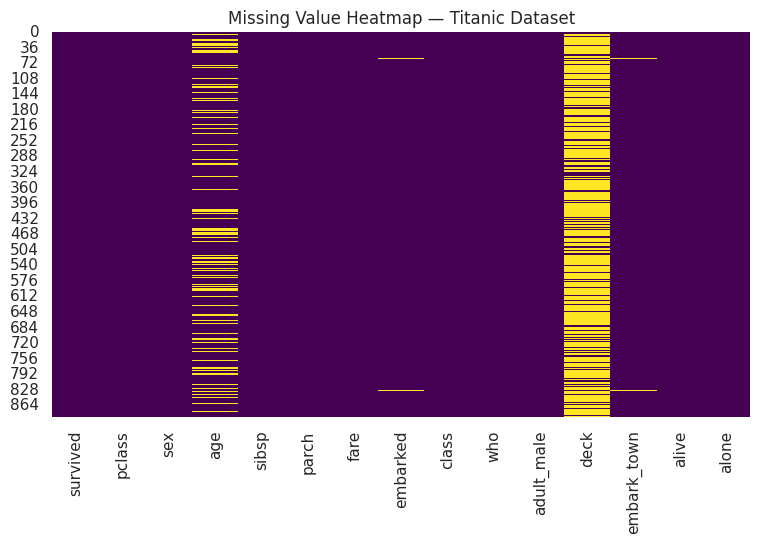

In [ ]:
# Visualization 1: Heatmap of missing values
plt.figure(figsize=(9, 5))
sns.heatmap(titanic.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap — Titanic Dataset")
plt.show()

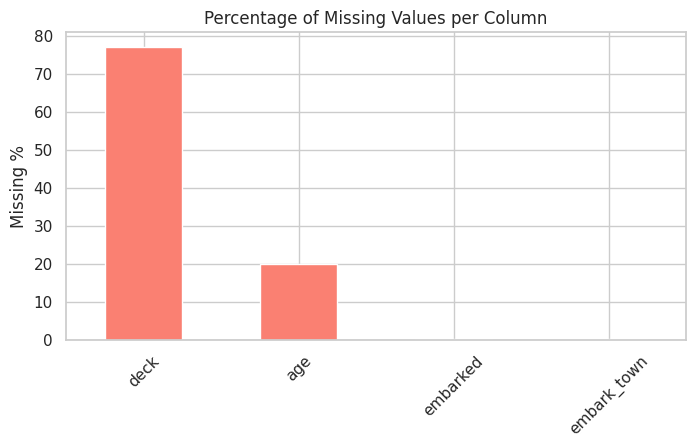

In [ ]:
# Visualization 2: Bar chart of missing value percentage
plt.figure(figsize=(8, 4))
missing_summary[missing_summary["Missing Count"] > 0]["Missing %"].plot(kind="bar", color="salmon")
plt.ylabel("Missing %")
plt.title("Percentage of Missing Values per Column")
plt.xticks(rotation=45)
plt.show()


### Handling Missing Values — Methods

In [ ]:
df_demo = titanic.copy()   # always work on a COPY, never the original!

# 1. Drop rows with any missing value (use sparingly — can lose a lot of data)
df_drop = df_demo.dropna()
print("After dropna():", df_drop.shape)

# 2. Fill numerical column with MEAN
df_demo["age_mean_filled"] = df_demo["age"].fillna(df_demo["age"].mean())

# 3. Fill numerical column with MEDIAN (better when data is skewed / has outliers)
df_demo["age_median_filled"] = df_demo["age"].fillna(df_demo["age"].median())

# 4. Fill categorical column with MODE (most frequent value)
df_demo["embarked_mode_filled"] = df_demo["embarked"].fillna(df_demo["embarked"].mode()[0])

# 5. Forward Fill — carry the previous valid value forward
df_demo["age_ffill"] = df_demo["age"].ffill()

# 6. Backward Fill — carry the next valid value backward
df_demo["age_bfill"] = df_demo["age"].bfill()

# 7. Interpolation — estimate missing values using surrounding data
df_demo["age_interpolated"] = df_demo["age"].interpolate()

# 8. Fill with a CONSTANT value
df_demo["deck_constant_filled"] = df_demo["deck"].astype("object").fillna("Unknown")

df_demo[["age", "age_mean_filled", "age_median_filled",
         "age_ffill", "age_bfill", "age_interpolated"]].head(8)

After dropna(): (182, 15)


,age,age_mean_filled,age_median_filled,age_ffill,age_bfill,age_interpolated
0,22.0,22.000000,22.0,22.0,22.0,22.0
1,38.0,38.000000,38.0,38.0,38.0,38.0
2,26.0,26.000000,26.0,26.0,26.0,26.0
3,35.0,35.000000,35.0,35.0,35.0,35.0
4,35.0,35.000000,35.0,35.0,35.0,35.0
5,NaN,29.699118,28.0,35.0,54.0,44.5
6,54.0,54.000000,54.0,54.0,54.0,54.0
7,2.0,2.000000,2.0,2.0,2.0,2.0


**Which method should you use?**

| Method | Best when |
|---|---|
| Drop | Very few missing rows, or the column is mostly missing (like `deck`) |
| Mean | Numerical data, roughly symmetric, no big outliers |
| Median | Numerical data, skewed or has outliers |
| Mode | Categorical data |
| Forward/Backward Fill | Time-series / ordered data |
| Interpolation | Numerical, ordered data with a smooth trend |
| Constant (e.g. "Unknown") | When "missing" itself is meaningful information |

>  **Common mistake:** Filling missing values *before* splitting data into train/test sets
> using statistics from the **whole** dataset — this leaks test-set information into training
> (called *data leakage*). In real ML projects, always fit fillers (mean/median) on the
> training set only.

###  Quick Check
- Why might `dropna()` be a bad idea for the `age` column but a reasonable idea for `deck`?

---
#  Duplicate Values

Duplicate rows happen due to data entry errors, merging datasets twice, or scraping errors.

In [ ]:
print("Number of duplicate rows in Titanic:", titanic.duplicated().sum())

# Let's create an artificial example to see duplicates in action
demo = titanic.head(5).copy()
demo = pd.concat([demo, demo.iloc[[0, 2]]], ignore_index=True)  # manually duplicate 2 rows
print("\nDemo dataset shape (with duplicates):", demo.shape)
print("Duplicate rows found:", demo.duplicated().sum())

demo[demo.duplicated(keep=False)]   # show all copies of duplicated rows

Number of duplicate rows in Titanic: 107

Demo dataset shape (with duplicates): (7, 15)
Duplicate rows found: 2


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
5,0,3,male,22.0,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
6,1,3,female,26.0,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True


In [ ]:
demo_cleaned = demo.drop_duplicates()
print("Shape before:", demo.shape, " | Shape after drop_duplicates():", demo_cleaned.shape)

Shape before: (7, 15)  | Shape after drop_duplicates(): (5, 15)


---
# Unique Values

In [ ]:
print("Unique classes in 'pclass':", titanic["pclass"].unique())
print("Number of unique classes  :", titanic["pclass"].nunique())

print("\nValue counts for 'embarked':")
print(titanic["embarked"].value_counts())

print("\nValue counts (as %) for 'sex':")
print(titanic["sex"].value_counts(normalize=True).round(3) * 100)

Unique classes in 'pclass': [3 1 2]
Number of unique classes  : 3

Value counts for 'embarked':
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Value counts (as %) for 'sex':
sex
male      64.8
female    35.2
Name: proportion, dtype: float64


**Interpretation:**
- `unique()` → lists the *distinct* values in a column.
- `nunique()` → counts how many distinct values exist (great for spotting ID-like columns
  or columns with only 1 unique value, both of which are useless for modelling).
- `value_counts()` → frequency of each category — instantly reveals **class imbalance**
  (e.g. far more passengers embarked from 'S' than 'Q').

>  **Tip:** If `nunique()` equals the number of rows, that column is likely an identifier
> (like `PassengerId`) and should usually be dropped before modelling.

---
#Correlation

Correlation measures how strongly two numerical variables move together, from **-1 to +1**.

```
   -1                      0                      +1
    │                      │                       │
Strong Negative        No relation           Strong Positive
(as X↑, Y↓)                                   (as X↑, Y↑)
```

- **Positive correlation** → both variables increase together (e.g. `fare` & `pclass`
  reversed, since 1st class = expensive).
- **Negative correlation** → one increases as the other decreases.
- **Zero / near-zero correlation** → no linear relationship.

>  Correlation ≠ Causation! Two variables can correlate strongly without one causing the other.

In [ ]:
numeric_titanic = titanic.select_dtypes(include=np.number)
corr_matrix = numeric_titanic.corr()
corr_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


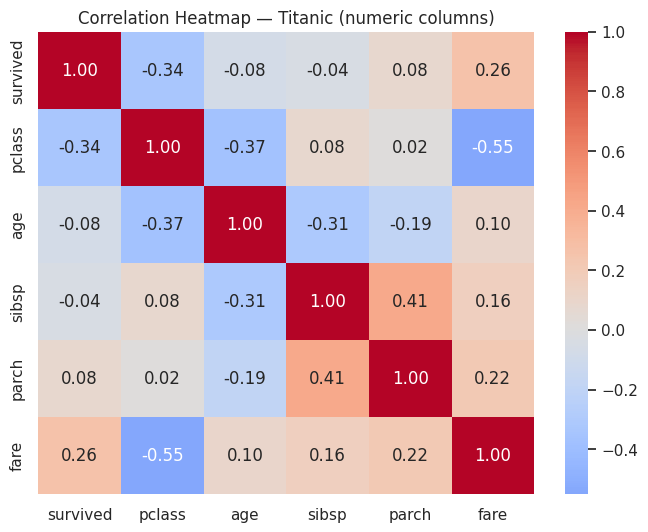

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Titanic (numeric columns)")
plt.show()

---
#Outliers

**Outliers** are data points that differ drastically from the rest of the data.

**Real-world examples:** a `Salary` of ₹5,00,00,000 in a dataset of ₹3–10 lakh salaries;
a `Height` of 240 cm; a student `Marks` of 105 out of 100 (data-entry error);
an `Income` of ₹0 in a working adults dataset.

### Method 1 — Boxplot (visual)

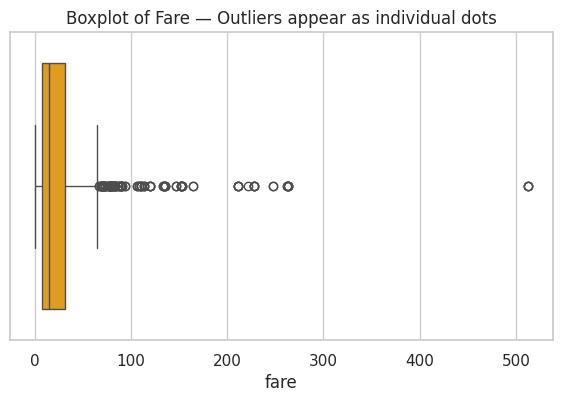

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=titanic["fare"], color="orange")
plt.title("Boxplot of Fare — Outliers appear as individual dots")
plt.show()

### Method 2 — IQR Rule (mathematical)

In [ ]:
Q1 = titanic["fare"].quantile(0.25)
Q3 = titanic["fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = titanic[(titanic["fare"] < lower_bound) | (titanic["fare"] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f}   Upper bound: {upper_bound:.2f}")
print("Number of outliers in 'fare':", outliers.shape[0])

Lower bound: -26.72   Upper bound: 65.63
Number of outliers in 'fare': 116


### Method 3 — Z-score (introduction)

In [ ]:
from scipy import stats

fare_no_na = titanic["fare"].dropna()
z_scores = np.abs(stats.zscore(fare_no_na))

z_outliers = fare_no_na[z_scores > 3]     # points more than 3 std-devs from the mean
print("Number of outliers using Z-score (|z| > 3):", z_outliers.shape[0])

Number of outliers using Z-score (|z| > 3): 20


In [ ]:
titanic_no_outliers = titanic[(titanic["fare"] >= lower_bound) & (titanic["fare"] <= upper_bound)]
print("Original shape :", titanic.shape)
print("After removing fare outliers:", titanic_no_outliers.shape)

Original shape : (891, 15)
After removing fare outliers: (775, 15)


>  **Common mistake:** Blindly deleting every outlier. Sometimes outliers are the
> *most important* data points (e.g. fraud detection, rare disease cases) — always
> investigate **why** a value is extreme before removing it.

---
# Feature Scaling

### Why scale data?
Many ML algorithms (KNN, SVM, K-Means, Gradient Descent-based models, Neural Networks) are
**distance-based** or **gradient-based**. If one feature ranges 0–1 and another 0–100,000,
the large-range feature will dominate the distance calculation / gradient — even if it isn't
actually more important!

```
WITHOUT SCALING                        WITH SCALING
Income: 0 ─────────────── 200000       Income: -1 ──── 0 ──── +1
Age:    0 ── 100                       Age:    -1 ──── 0 ──── +1
   (Income completely dominates)          (Both features contribute fairly)
```

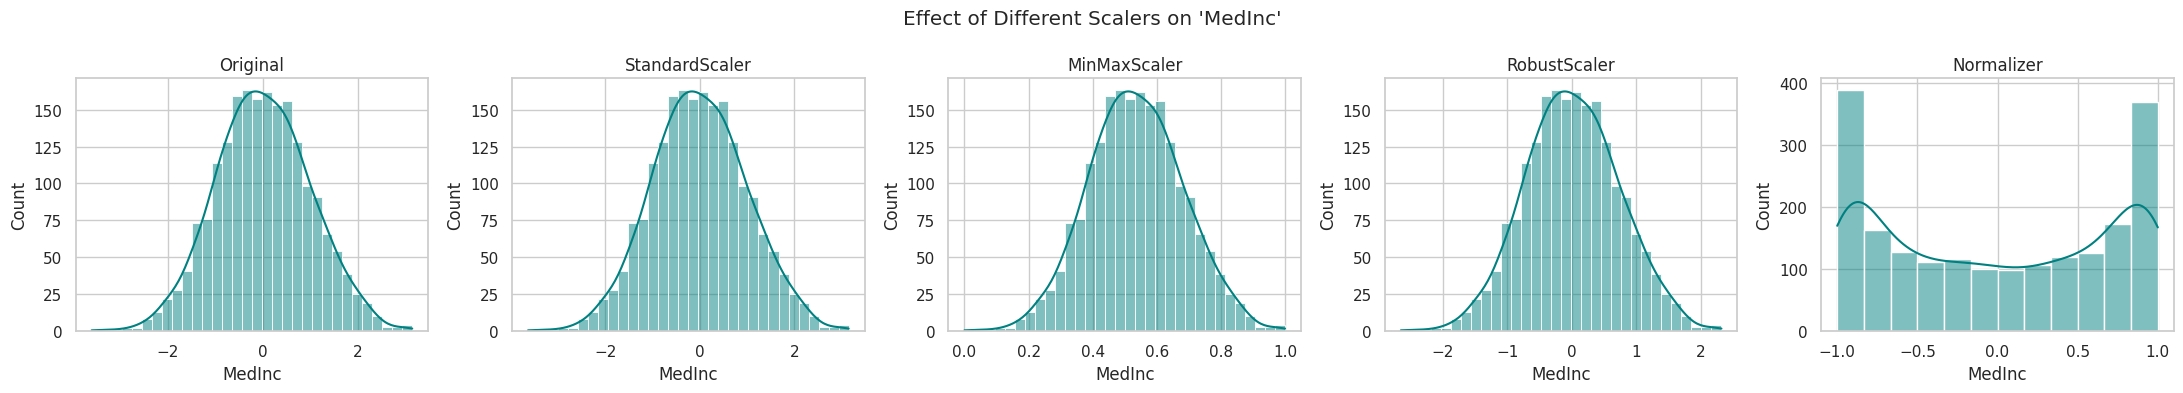

In [ ]:
housing_num = housing.select_dtypes(include=np.number).dropna()
sample_cols = housing_num.columns[:2]   # take 2 numeric columns to compare visually

scalers = {
    "Original":        housing_num[sample_cols],
    "StandardScaler":  pd.DataFrame(StandardScaler().fit_transform(housing_num[sample_cols]), columns=sample_cols),
    "MinMaxScaler":    pd.DataFrame(MinMaxScaler().fit_transform(housing_num[sample_cols]),   columns=sample_cols),
    "RobustScaler":    pd.DataFrame(RobustScaler().fit_transform(housing_num[sample_cols]),   columns=sample_cols),
    "Normalizer":      pd.DataFrame(Normalizer().fit_transform(housing_num[sample_cols]),     columns=sample_cols),
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    sns.histplot(data[sample_cols[0]], ax=ax, kde=True, color="teal")
    ax.set_title(name)
plt.suptitle(f"Effect of Different Scalers on '{sample_cols[0]}'")
plt.tight_layout()
plt.show()

| Scaler | What it does | Best when |
|---|---|---|
| **StandardScaler** | Mean = 0, Std = 1 | Data roughly follows a normal distribution |
| **MinMaxScaler** | Squeezes values into [0, 1] | You need bounded ranges (e.g. neural nets) |
| **RobustScaler** | Uses median & IQR instead of mean/std | Data has many outliers |
| **Normalizer** | Scales each *row* to unit norm | Row-wise comparisons (e.g. text/vector data) |

>  **Tip:** Tree-based models (Decision Tree, Random Forest, XGBoost) do **not** require
> feature scaling — they split on thresholds, not distances.

###  Quick Check
- Why would `MinMaxScaler` be risky on a column that has extreme outliers?

---
# Encoding Categorical Data

ML algorithms need **numbers**, not text — encoding converts categories into numeric form.

In [ ]:
demo_enc = titanic[["sex", "embarked", "pclass"]].dropna().copy()

# 1. Label Encoding — assigns each category an integer (0, 1, 2, ...)
le = LabelEncoder()
demo_enc["sex_label"] = le.fit_transform(demo_enc["sex"])

# 2. One-Hot Encoding — creates a separate 0/1 column for every category
one_hot = pd.get_dummies(demo_enc["embarked"], prefix="embarked")

# 3. Ordinal Encoding — like Label Encoding, but you CONTROL the order
#    (pclass 1 = best, 3 = worst, so we keep that natural order)
ordinal = OrdinalEncoder(categories=[[1, 2, 3]])
demo_enc["pclass_ordinal"] = ordinal.fit_transform(demo_enc[["pclass"]])

result = pd.concat([demo_enc[["sex", "sex_label"]], one_hot,
                     demo_enc[["pclass", "pclass_ordinal"]]], axis=1)
result.head()

,sex,sex_label,embarked_C,embarked_Q,embarked_S,pclass,pclass_ordinal
0,male,1,False,False,True,3,2.0
1,female,0,True,False,False,1,0.0
2,female,0,False,False,True,3,2.0
3,female,0,False,False,True,1,0.0
4,male,1,False,False,True,3,2.0


| Method | How it works | Use for |
|---|---|---|
| **Label Encoding** | Category → single integer | Ordinal data, or tree-based models |
| **One-Hot Encoding** | Category → multiple 0/1 columns | Nominal data (no order), linear models |
| **Ordinal Encoding** | Category → integer, in a *meaningful* order | Data with a clear rank (Low/Medium/High) |
| **Binary Encoding** *(intro)* | Category → binary code split across fewer columns | High-cardinality categorical columns |

>  **Common mistake:** Using plain **Label Encoding** on a *nominal* column like `embarked`
> ('C', 'Q', 'S'). It implies a false order (C < Q < S) that many algorithms will
> misinterpret as meaningful — use **One-Hot Encoding** instead for nominal data.

---
# Data Visualization — The Complete Toolkit

This is the **biggest and most important section**. For each plot type you'll see:
**Purpose → When to use → Code → Interpretation**. We'll mix Titanic, Iris, and Tips
datasets to show each plot on the data it suits best.

###  1. Histogram
**Purpose:** Shows the *distribution* (shape/spread) of a single numerical variable.
**When to use:** Understanding how one numeric column is spread out — skewed? normal? bimodal?

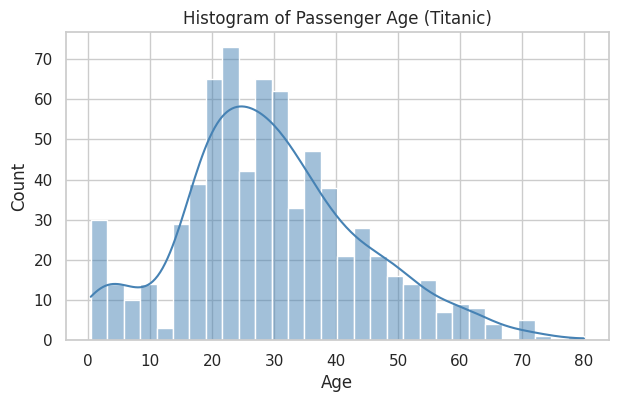

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(titanic["age"], bins=30, kde=True, color="steelblue")
plt.title("Histogram of Passenger Age (Titanic)")
plt.xlabel("Age")
plt.show()

###  2. Countplot
**Purpose:** Shows the *frequency* of each category in a categorical column.
**When to use:** Comparing counts across categories (class imbalance checks).

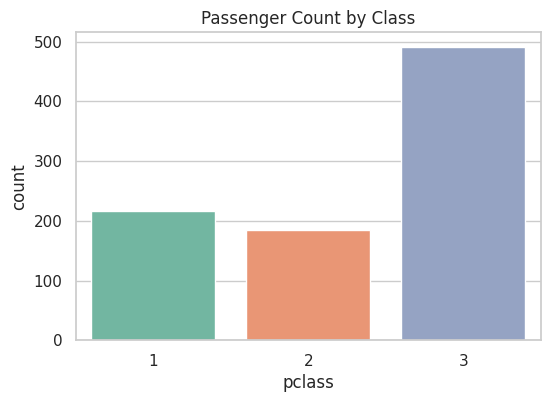

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="pclass", data=titanic, hue="pclass", palette="Set2", legend=False)
plt.title("Passenger Count by Class")
plt.show()

###  3. Barplot
**Purpose:** Shows the *average* (or another statistic) of a numeric variable across categories.
**When to use:** Comparing a summary statistic (like mean survival rate) between groups.

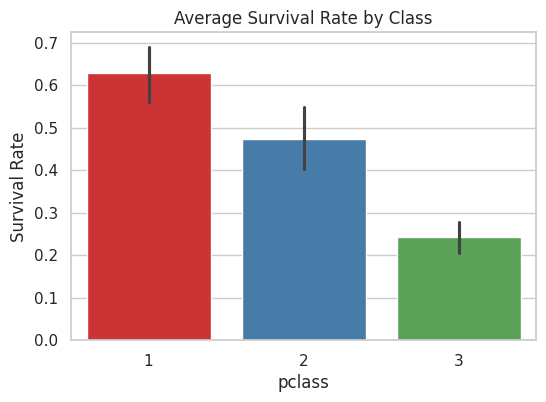

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x="pclass", y="survived", data=titanic, hue="pclass", palette="Set1", legend=False)
plt.title("Average Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.show()

###  4. Boxplot
**Purpose:** Shows median, quartiles, and outliers of a numeric variable — optionally split by category.
**When to use:** Comparing distributions & spotting outliers across groups.

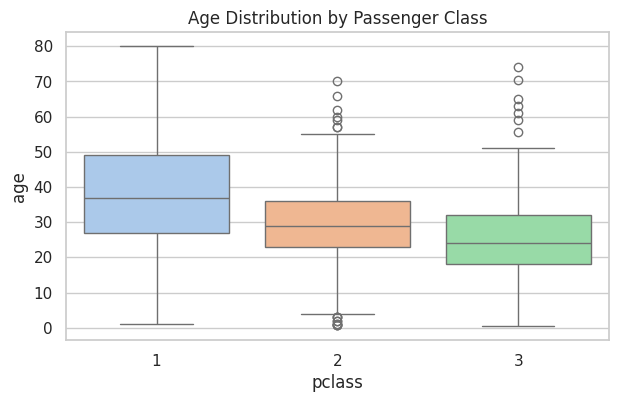

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="pclass", y="age", data=titanic, hue="pclass", palette="pastel", legend=False)
plt.title("Age Distribution by Passenger Class")
plt.show()

###  5. Violin Plot
**Purpose:** Combines a boxplot with a KDE (density) curve, showing the full *shape* of the distribution.
**When to use:** When you want more distributional detail than a boxplot alone gives.

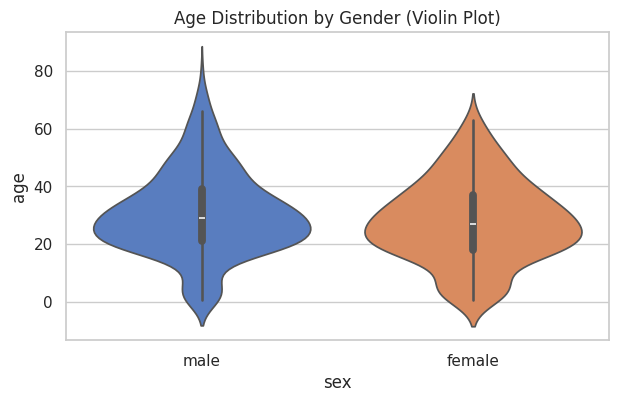

In [ ]:
plt.figure(figsize=(7, 4))
sns.violinplot(x="sex", y="age", data=titanic, hue="sex", palette="muted", legend=False)
plt.title("Age Distribution by Gender (Violin Plot)")
plt.show()

###  6. Scatter Plot
**Purpose:** Shows the relationship between **two** numerical variables.
**When to use:** Spotting correlation, trends, or clusters between two continuous variables.

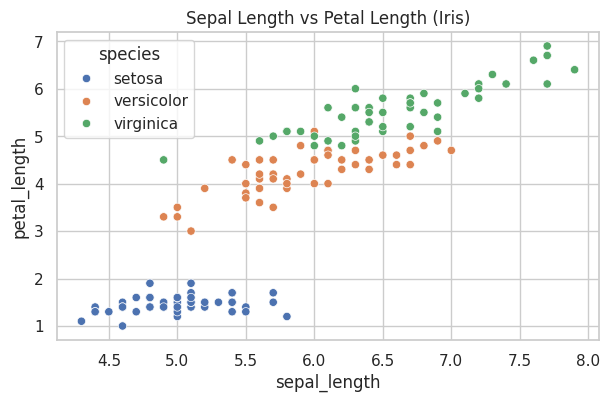

In [ ]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=iris, palette="deep")
plt.title("Sepal Length vs Petal Length (Iris)")
plt.show()

###  7. Pairplot
**Purpose:** Plots every pair of numerical columns against each other in one grid, with
histograms on the diagonal.
**When to use:** A fast, complete first look at relationships between *all* numeric features.

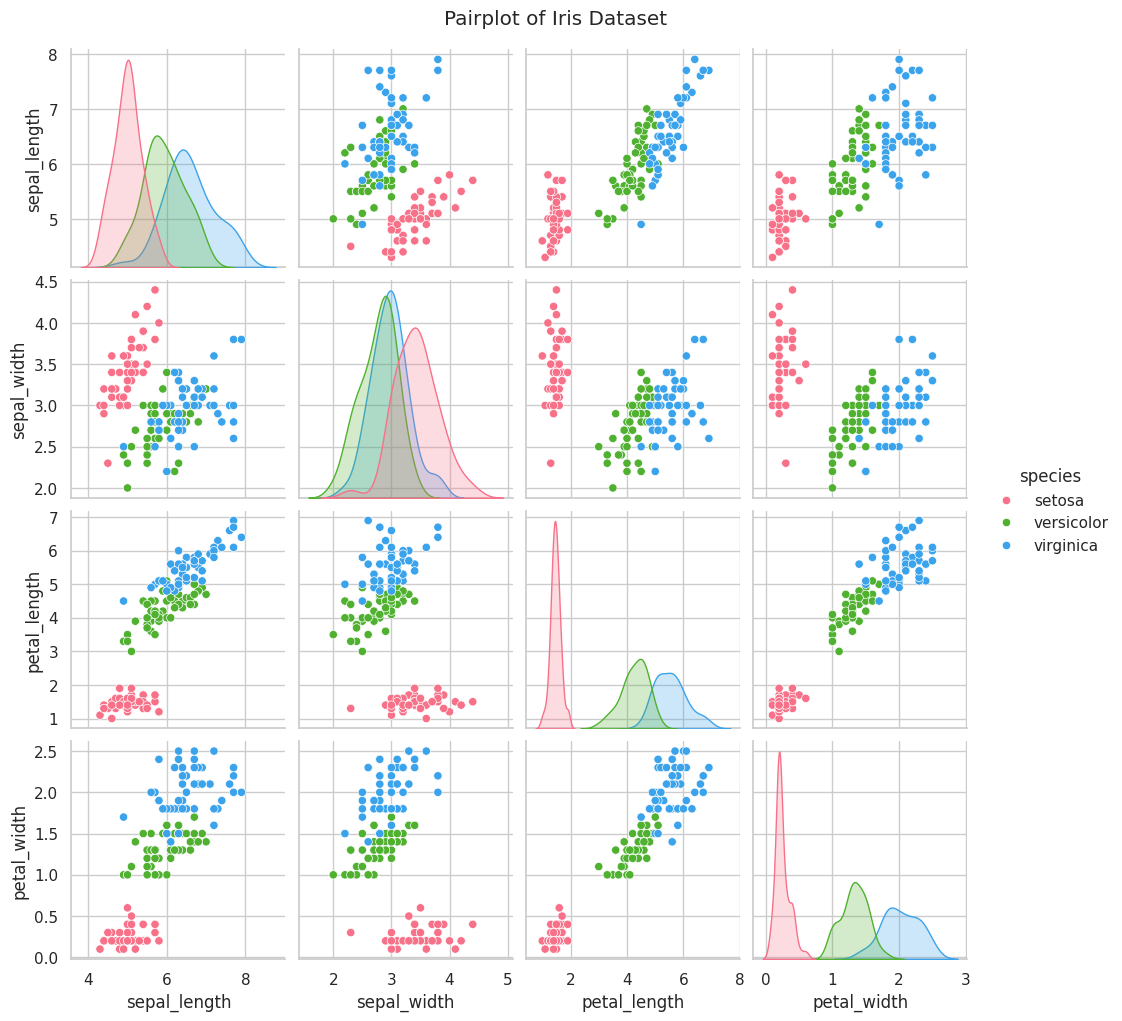

In [ ]:
sns.pairplot(iris, hue="species", palette="husl", diag_kind="kde")
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

###  8. Heatmap
**Purpose:** Visualizes a matrix of values (commonly correlation) using color intensity.
**When to use:** Spotting strong positive/negative relationships across many variables at once (already used in Section 11!).

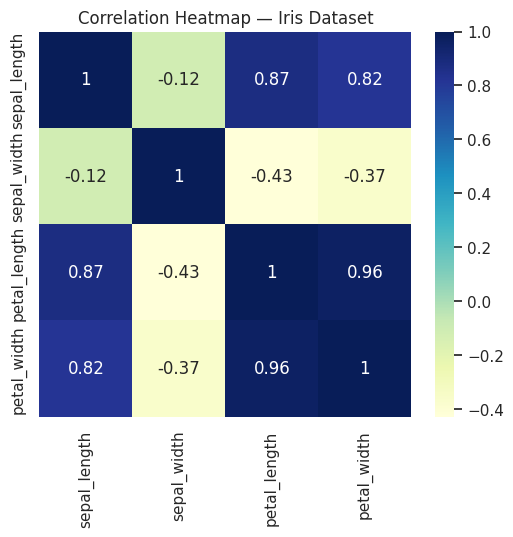

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(iris.drop(columns="species").corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap — Iris Dataset")
plt.show()

###  9. Line Plot
**Purpose:** Shows a trend of a numeric variable, typically over an ordered axis (time, sequence).
**When to use:** Time-series data, or any variable naturally ordered along the x-axis.

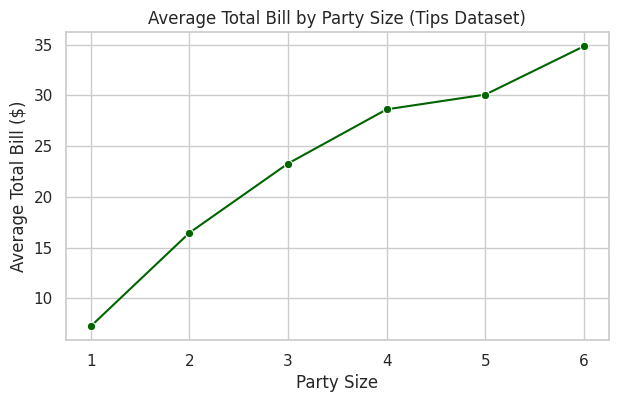

In [ ]:
bill_by_size = tips.groupby("size")["total_bill"].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.lineplot(x="size", y="total_bill", data=bill_by_size, marker="o", color="darkgreen")
plt.title("Average Total Bill by Party Size (Tips Dataset)")
plt.xlabel("Party Size")
plt.ylabel("Average Total Bill ($)")
plt.show()

###  10. Pie Chart
**Purpose:** Shows the *proportion* each category contributes to the whole.
**When to use:** A small number of categories (2–6) where showing "share of total" matters.

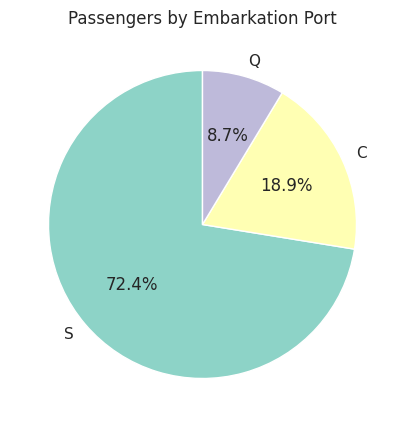

In [ ]:
plt.figure(figsize=(5, 5))
titanic["embarked"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=sns.color_palette("Set3"), startangle=90)
plt.title("Passengers by Embarkation Port")
plt.ylabel("")
plt.show()

**Interpretation:** Over 72% of passengers embarked from Southampton ('S'), a much smaller
share from Cherbourg ('C') and Queenstown ('Q').

>  **Common mistake:** Using pie charts for *many* categories (8+) — they become
> unreadable. A barplot is almost always a better choice beyond a handful of categories.

###  11. KDE Plot (Kernel Density Estimate)
**Purpose:** A smoothed, continuous version of a histogram — shows the estimated
probability density of a variable.
**When to use:** Comparing the *shape* of distributions across groups smoothly.

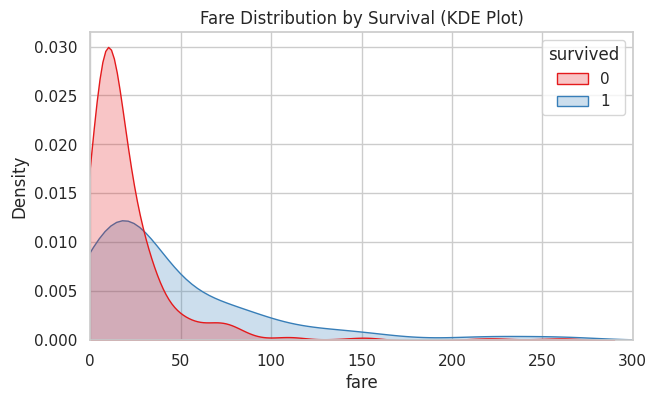

In [ ]:
plt.figure(figsize=(7, 4))
sns.kdeplot(data=titanic, x="fare", hue="survived", fill=True, common_norm=False, palette="Set1")
plt.title("Fare Distribution by Survival (KDE Plot)")
plt.xlim(0, 300)
plt.show()

###  12. Strip Plot
**Purpose:** Plots every individual data point along a categorical axis (with slight jitter).
**When to use:** Small-to-medium datasets, when you want to see *every* raw point, not just a summary.

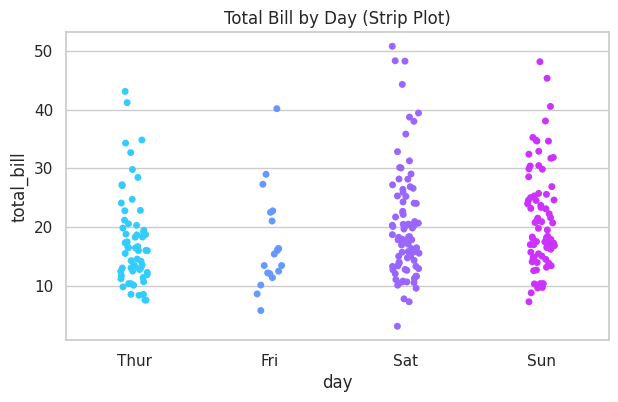

In [ ]:
plt.figure(figsize=(7, 4))
sns.stripplot(x="day", y="total_bill", data=tips, hue="day", jitter=True, palette="cool", legend=False)
plt.title("Total Bill by Day (Strip Plot)")
plt.show()

###  13. Swarm Plot
**Purpose:** Like a strip plot, but points are arranged to *never overlap* — shows density more clearly.
**When to use:** Small datasets where you want an accurate, non-overlapping view of every point.

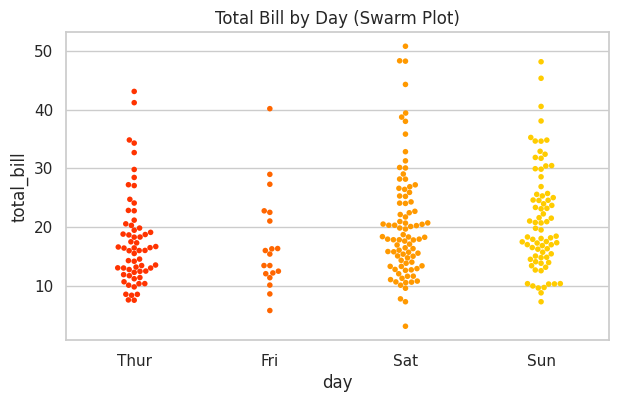

In [ ]:
plt.figure(figsize=(7, 4))
sns.swarmplot(x="day", y="total_bill", data=tips, hue="day", palette="autumn", size=4, legend=False)
plt.title("Total Bill by Day (Swarm Plot)")
plt.show()

###  14. Jointplot
**Purpose:** Combines a scatter plot with histograms of both variables on the margins.
**When to use:** Studying the relationship between two numeric variables *and* their individual distributions together.

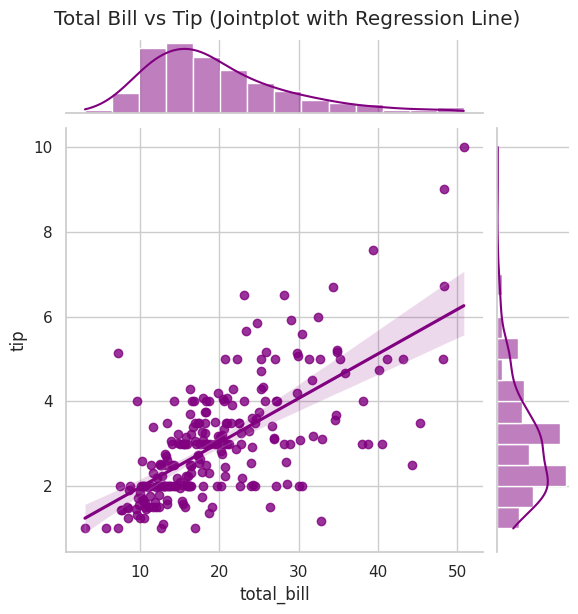

In [ ]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind="reg", color="purple", height=6)
plt.suptitle("Total Bill vs Tip (Jointplot with Regression Line)", y=1.02)
plt.show()

###  15. Rug Plot
**Purpose:** Draws a small tick for every single data point along an axis — often layered under another plot.
**When to use:** Adding raw data density detail underneath a histogram/KDE without extra clutter.

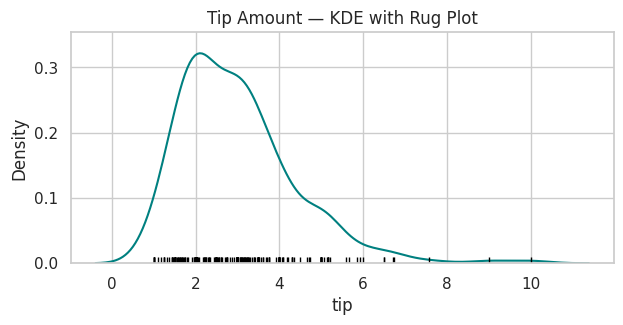

In [ ]:
plt.figure(figsize=(7, 3))
sns.kdeplot(tips["tip"], color="teal")
sns.rugplot(tips["tip"], color="black")
plt.title("Tip Amount — KDE with Rug Plot")
plt.show()

###  16. ECDF Plot (Empirical Cumulative Distribution Function)
**Purpose:** Shows what proportion of the data lies *at or below* each value.
**When to use:** Comparing distributions precisely — answers "what % of values are under X?" directly.

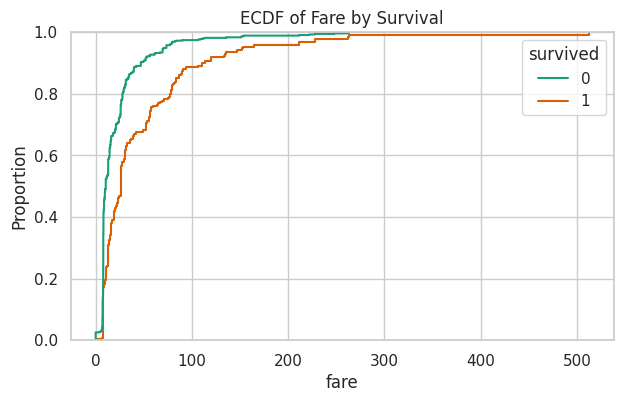

In [ ]:
plt.figure(figsize=(7, 4))
sns.ecdfplot(data=titanic, x="fare", hue="survived", palette="Dark2")
plt.title("ECDF of Fare by Survival")
plt.show()

**Interpretation:** At any fare value, you can read off the cumulative % of passengers at or
below it. The non-survivors' curve rises faster at low fares — confirming they paid less on
average than survivors.

###  Quick Check
- Which plot would you use to compare the *distribution shape* of `tip` between lunch and dinner?
- Which plot best shows the relationship between `total_bill` and `tip` together with their individual distributions?

###  Mini Assignment
Using the **Tips** dataset, create:
1. A boxplot of `total_bill` grouped by `time` (Lunch/Dinner).
2. A scatter plot of `total_bill` vs `tip`, colored by `smoker`.
3. Write 2 sentences interpreting each plot.

---
# GroupBy & Aggregation

`groupby()` is one of the most powerful Pandas tools — it lets you **split** data into
groups, **apply** a function to each group, and **combine** the results ("split-apply-combine").

In [ ]:
# groupby() + single aggregation
tips.groupby("day", observed=True)["total_bill"].mean()

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64

In [ ]:
# groupby() + agg() with multiple statistics at once
tips.groupby("day", observed=True)["total_bill"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
day,,,,
Thur,17.682742,16.20,7.886170,62
Fri,17.151579,15.38,8.302660,19
Sat,20.441379,18.24,9.480419,87
Sun,21.410000,19.63,8.832122,76


In [ ]:
# groupby() with multiple columns
tips.groupby(["day", "time"], observed=True)["tip"].mean().unstack()

time,Lunch,Dinner
day,,
Thur,2.767705,3.000000
Fri,2.382857,2.940000
Sat,NaN,2.993103
Sun,NaN,3.255132


In [ ]:
# pivot_table() — similar to groupby, but in a spreadsheet-like format
pd.pivot_table(tips, values="total_bill", index="day", columns="time",
                aggfunc="mean", observed=True)

time,Lunch,Dinner
day,,
Thur,17.664754,18.780000
Fri,12.845714,19.663333
Sat,NaN,20.441379
Sun,NaN,21.410000


In [ ]:
# crosstab() — frequency table between two categorical columns
pd.crosstab(titanic["pclass"], titanic["survived"], margins=True)

survived,0,1,All
pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


---
# Full Data Cleaning Project — Titanic

Let's put **everything together** into one complete, real cleaning pipeline — exactly what
you'd do before feeding this data into a Machine Learning model.

In [ ]:
# Start fresh with a clean copy
clean_df = titanic.copy()
print("Starting shape:", clean_df.shape)
clean_df.head()

Starting shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Step 1 — Handle Missing Values

In [ ]:
# 'age' -> fill with median (skewed, has outliers)
clean_df["age"] = clean_df["age"].fillna(clean_df["age"].median())

# 'embarked' -> fill with mode (categorical, very few missing)
clean_df["embarked"] = clean_df["embarked"].fillna(clean_df["embarked"].mode()[0])

# 'deck' -> too many missing (~77%) -> drop the column entirely
clean_df = clean_df.drop(columns=["deck"])

# drop rows still missing anything critical (safety net)
clean_df = clean_df.dropna(subset=["embark_town"])

print("Missing values remaining:\n", clean_df.isnull().sum()[clean_df.isnull().sum() > 0])

Missing values remaining:
 Series([], dtype: int64)


### Step 2 — Remove Duplicate Rows

In [ ]:
before = clean_df.shape[0]
clean_df = clean_df.drop_duplicates()
after = clean_df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {clean_df.shape}")

Removed 116 duplicate rows. New shape: (773, 14)


### Step 3 — Outlier Detection & Treatment (fare)

In [ ]:
Q1, Q3 = clean_df["fare"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

n_outliers = clean_df[(clean_df["fare"] < lower) | (clean_df["fare"] > upper)].shape[0]
print(f"Fare outliers detected: {n_outliers}")

# Cap (winsorize) rather than delete, to avoid losing too many rows
clean_df["fare"] = clean_df["fare"].clip(lower=lower, upper=upper)
print("Fare range after capping:", clean_df["fare"].min(), "-", clean_df["fare"].max())

Fare outliers detected: 100
Fare range after capping: 0.0 - 71.675


### Step 4 — Encode Categorical Columns

In [ ]:
# Drop redundant / high-cardinality / identifier-like columns first
clean_df = clean_df.drop(columns=["who", "adult_male", "alive", "class", "embark_town"])

# One-Hot Encode nominal columns
clean_df = pd.get_dummies(clean_df, columns=["sex", "embarked"], drop_first=True)

clean_df.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,True,False,True


### Step 5 — Feature Scaling

In [ ]:
num_cols = ["age", "fare"]
scaler = StandardScaler()
clean_df[num_cols] = scaler.fit_transform(clean_df[num_cols])

clean_df[num_cols].describe().round(2)

,age,fare
count,773.00,773.00
mean,0.00,-0.00
std,1.00,1.00
min,-2.12,-1.18
25%,-0.62,-0.82
50%,-0.11,-0.46
75%,0.47,0.33
max,3.68,2.04


### Step 6 — Final Clean Dataset

In [ ]:
print("Final cleaned shape:", clean_df.shape)
print("\nRemaining missing values:", clean_df.isnull().sum().sum())
clean_df.head()

Final cleaned shape: (773, 10)

Remaining missing values: 0


,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,-0.548619,1,0,-0.851827,False,True,False,True
1,1,1,0.617360,1,0,2.019543,False,False,False,False
2,1,3,-0.257124,0,0,-0.821559,True,False,False,True
3,1,1,0.398739,1,0,1.204170,False,False,False,True
4,0,3,0.398739,0,0,-0.815954,True,True,False,True


In [ ]:
# Save the final cleaned dataset to CSV
clean_df.to_csv("titanic_cleaned.csv", index=False)
print(" Saved as 'titanic_cleaned.csv'")

✅ Saved as 'titanic_cleaned.csv'


>  **Best practice recap:** collect → inspect → handle missing values → remove duplicates
> → treat outliers → encode → scale → save. This exact order avoids most data leakage and
> preprocessing mistakes.

---
# Mini Guided EDA Project — Tips Dataset

Now it's **your turn**! Follow the guided steps below, filling in the `# TODO` lines.
A worked example is shown for the first step — try the rest yourself before checking
Section 24's cheat sheet.

In [ ]:
# STEP 1 (example, already solved): First look at the data
print(tips.shape)
tips.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# STEP 2: Check for missing values
# TODO: use isnull().sum() on the tips dataset
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [ ]:
# STEP 3: Check for duplicate rows
# TODO: use duplicated().sum()
tips.duplicated().sum()

np.int64(1)

In [ ]:
# STEP 4: Get summary statistics
# TODO: use describe()
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


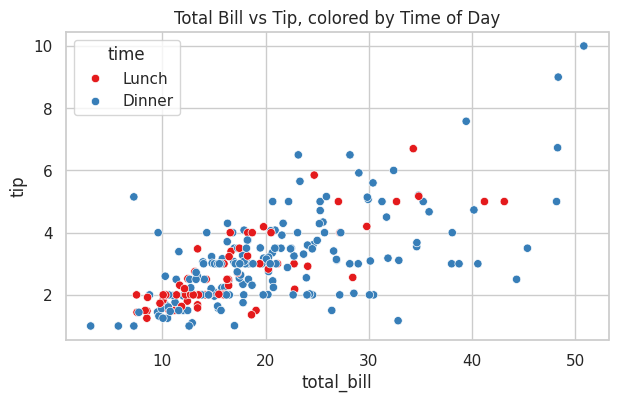

In [ ]:
# STEP 5: Visualize the relationship between total_bill and tip
# TODO: create a scatter plot, colored by 'time'
plt.figure(figsize=(7, 4))
sns.scatterplot(x="total_bill", y="tip", hue="time", data=tips, palette="Set1")
plt.title("Total Bill vs Tip, colored by Time of Day")
plt.show()

In [ ]:
# Reload the tips dataset (and others) to ensure it's defined
import seaborn as sns
titanic  = sns.load_dataset("titanic")
iris     = sns.load_dataset("iris")
tips     = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
print("Datasets reloaded.")

Datasets reloaded.


### Mini Assignment Solutions

#### 1. What is the average tip percentage (`tip / total_bill * 100`)? Add it as a new column.

In [ ]:
# Calculate tip percentage and add as a new column
tips['tip_percentage'] = (tips['tip'] / tips['total_bill'] * 100).round(2)
print("Tips dataset with 'tip_percentage' column:")
display(tips.head())

Tips dataset with 'tip_percentage' column:


,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


#### 2. Which day has the highest average tip percentage?

In [ ]:
# Calculate average tip percentage by day
average_tip_percent_by_day = tips.groupby('day')['tip_percentage'].mean().sort_values(ascending=False)
print("Average tip percentage by day:")
display(average_tip_percent_by_day)

highest_tip_day = average_tip_percent_by_day.index[0]
highest_tip_value = average_tip_percent_by_day.iloc[0]
print(f"\nThe day with the highest average tip percentage is: {highest_tip_day} with {highest_tip_value:.2f}%\n")

Average tip percentage by day:


/tmp/ipykernel_1183/33371110.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_tip_percent_by_day = tips.groupby('day')['tip_percentage'].mean().sort_values(ascending=False)


,tip_percentage
day,
Fri,16.991579
Sun,16.689605
Thur,16.126452
Sat,15.314598



The day with the highest average tip percentage is: Fri with 16.99%



#### 3. Do smokers tip more or less than non-smokers, on average?

In [ ]:
# Compare average tip percentage between smokers and non-smokers
average_tip_percent_by_smoker = tips.groupby('smoker')['tip_percentage'].mean()
print("Average tip percentage by smoker status:")
display(average_tip_percent_by_smoker)

if average_tip_percent_by_smoker['Yes'] > average_tip_percent_by_smoker['No']:
    print("\nOn average, smokers tip slightly more than non-smokers.\n")
else:
    print("\nOn average, non-smokers tip slightly more than smokers.\n")

Average tip percentage by smoker status:


/tmp/ipykernel_1183/1355255434.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_tip_percent_by_smoker = tips.groupby('smoker')['tip_percentage'].mean()


,tip_percentage
smoker,
Yes,16.319140
No,15.932318



On average, smokers tip slightly more than non-smokers.



---
# Programming Exercises

Complete each `# TODO` below yourself. Solutions are commented out — try first!

In [ ]:
# Exercise 1: Load Iris and print the first five rows
# TODO: complete this
iris_ex = sns.load_dataset("iris")
print(iris_ex.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
# Exercise 2: Find missing values in the Titanic dataset
# TODO: complete this
print(titanic.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
# Exercise 3: Remove duplicate rows from the Tips dataset (if any)
# TODO: complete this
tips_no_dup = tips.drop_duplicates()
print("Before:", tips.shape, "After:", tips_no_dup.shape)

Before: (244, 7) After: (243, 7)


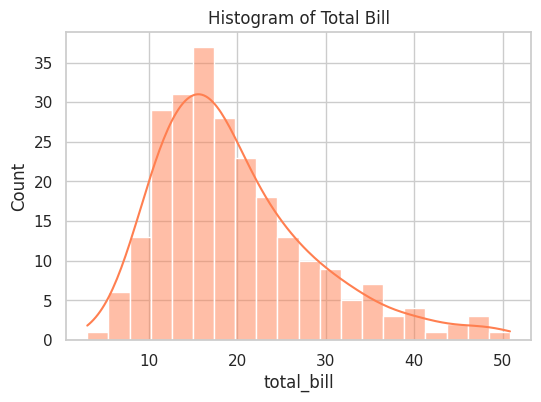

In [ ]:
# Exercise 4: Plot a histogram of the 'total_bill' column from Tips
# TODO: complete this
plt.figure(figsize=(6, 4))
sns.histplot(tips["total_bill"], bins=20, kde=True, color="coral")
plt.title("Histogram of Total Bill")
plt.show()

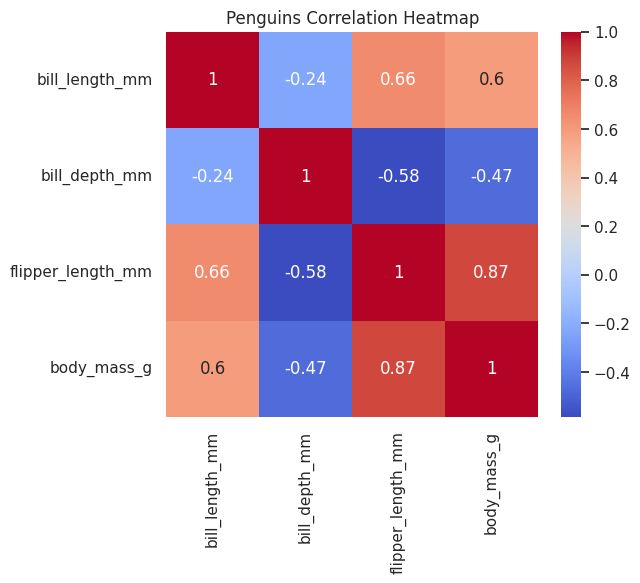

In [ ]:
# Exercise 5: Create a correlation heatmap for the Penguins dataset
# TODO: complete this
plt.figure(figsize=(6, 5))
sns.heatmap(penguins.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Penguins Correlation Heatmap")
plt.show()

---
# Mini Assignment — Full EDA on the Penguins Dataset

Perform a complete EDA on the `penguins` dataset (already loaded) and answer the following
in new cells below. This is meant to be done **independently** — use everything you've
learned in this notebook!

1. Number of rows and columns
2. Number of missing values (per column)
3. Number of duplicate rows
4. A correlation matrix / heatmap of the numeric columns
5. A boxplot showing `bill_length_mm` grouped by `species`
6. A pairplot colored by `species`
7. A fully cleaned version of the dataset (missing values handled, duplicates removed)

Use the empty code cell below to get started:

### Mini Assignment Solutions — Penguins Dataset

#### 1. Number of rows and columns

In [ ]:
print(f"Number of rows: {penguins.shape[0]}")
print(f"Number of columns: {penguins.shape[1]}")

Number of rows: 344
Number of columns: 7


#### 2. Number of missing values (per column)

In [ ]:
print("Missing values per column:")
display(penguins.isnull().sum())

Missing values per column:


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


#### 3. Number of duplicate rows

In [ ]:
print(f"Number of duplicate rows: {penguins.duplicated().sum()}")

Number of duplicate rows: 0


#### 4. A correlation matrix / heatmap of the numeric columns

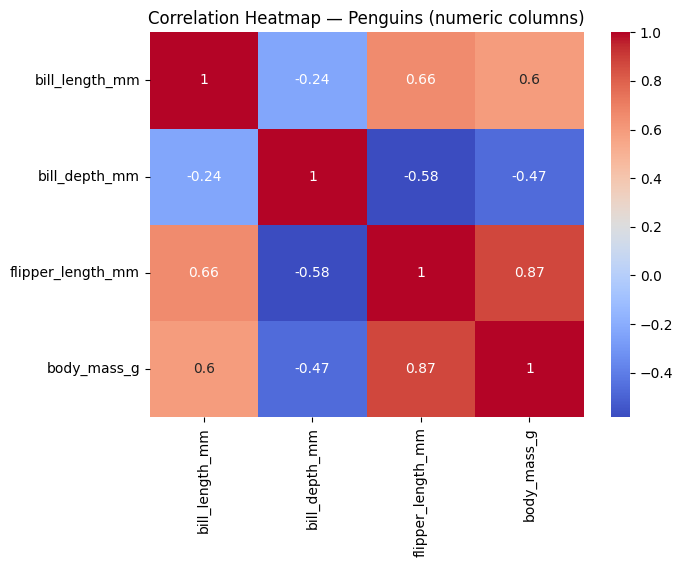

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(7, 5))
sns.heatmap(penguins.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap — Penguins (numeric columns)")
plt.show()

#### 5. A boxplot showing `bill_length_mm` grouped by `species`

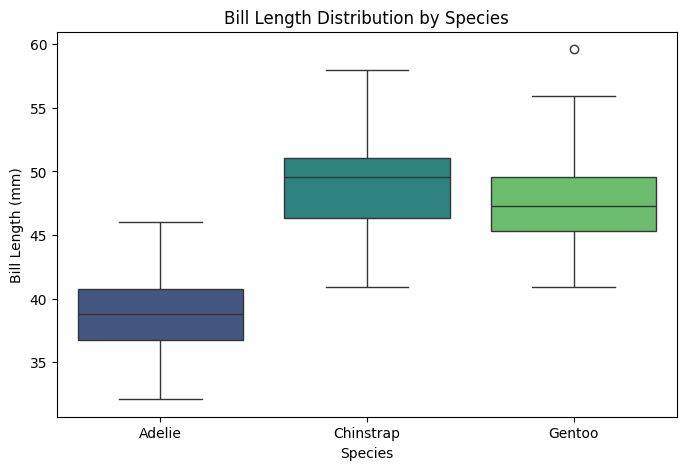

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="species", y="bill_length_mm", data=penguins, hue="species", palette="viridis", legend=False)
plt.title("Bill Length Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Bill Length (mm)")
plt.show()

#### 6. A pairplot colored by `species`

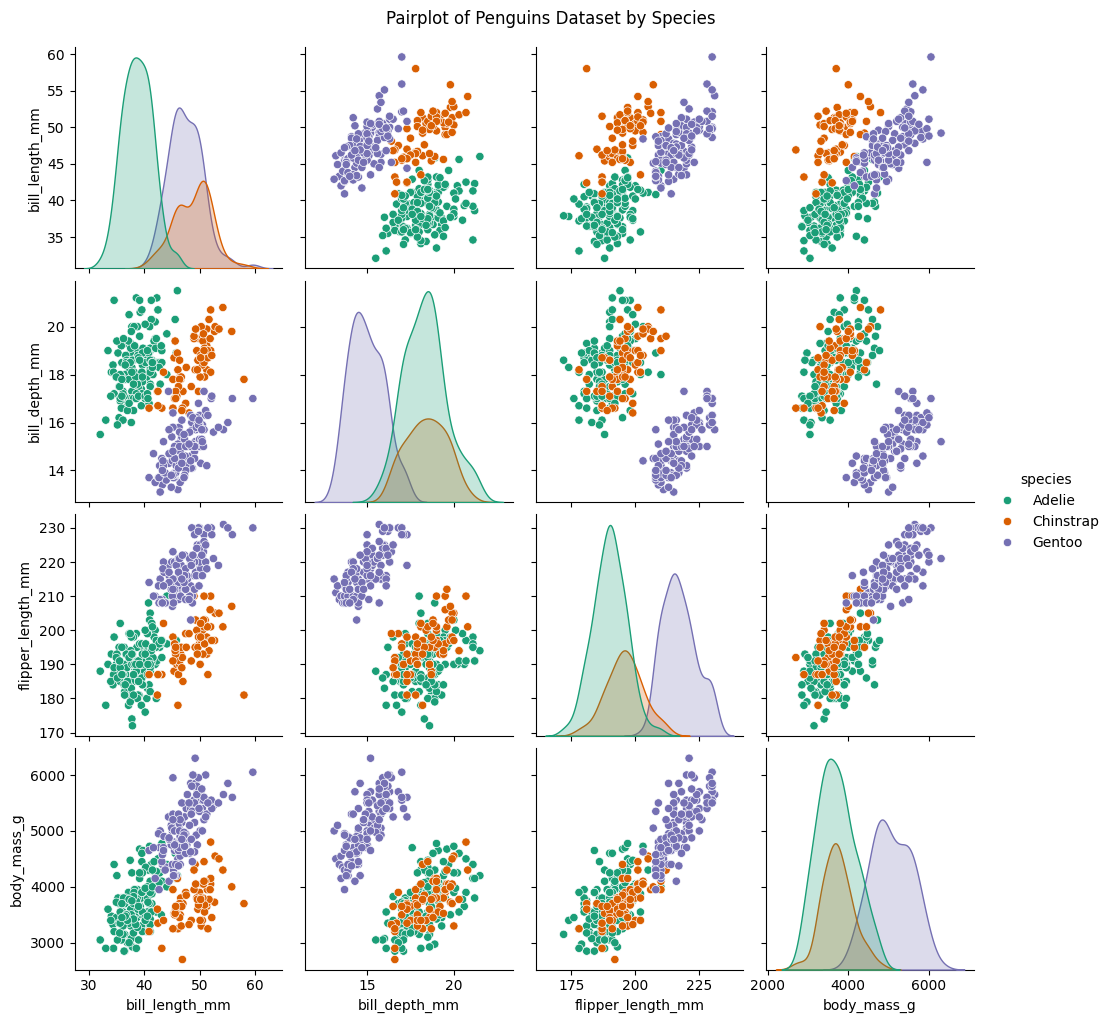

In [ ]:
sns.pairplot(penguins, hue="species", palette="Dark2", diag_kind="kde")
plt.suptitle("Pairplot of Penguins Dataset by Species", y=1.02)
plt.show()

#### 7. A fully cleaned version of the dataset (missing values handled, duplicates removed)

In [ ]:
# Create a copy to avoid modifying the original DataFrame
cleaned_penguins = penguins.copy()

# Remove duplicate rows
before_duplicates = cleaned_penguins.shape[0]
cleaned_penguins.drop_duplicates(inplace=True)
after_duplicates = cleaned_penguins.shape[0]
print(f"Removed {before_duplicates - after_duplicates} duplicate rows.")

# Handle missing values by dropping rows with any NaN, as there are relatively few (11 out of 344 original rows)
# This is a common strategy for a first pass in mini assignments
before_missing = cleaned_penguins.shape[0]
cleaned_penguins.dropna(inplace=True)
after_missing = cleaned_penguins.shape[0]
print(f"Removed {before_missing - after_missing} rows with missing values.")

print(f"\nFinal cleaned dataset shape: {cleaned_penguins.shape}")
print("Remaining missing values:")
display(cleaned_penguins.isnull().sum())
print("\nFirst 5 rows of the cleaned dataset:")
display(cleaned_penguins.head())

Removed 0 duplicate rows.
Removed 11 rows with missing values.

Final cleaned dataset shape: (333, 7)
Remaining missing values:


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0



First 5 rows of the cleaned dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
